# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# Week 5 Assignment
## Text Generation using Vanilla RNN, LSTM, and GRU

### Submitted By:
Name: Preetam Sharma

### Objective
To compare the performance of SimpleRNN, LSTM, and GRU architectures for next-word prediction and text generation.

### Technologies Used
- Python
- TensorFlow / Keras
- NumPy
- Matplotlib

# 1. Introduction

Recurrent Neural Networks (RNNs) are widely used for sequential data such as text. They learn dependencies between words and can generate meaningful text.

In this assignment, three architectures are implemented:

1. Vanilla RNN (SimpleRNN)
2. Long Short-Term Memory (LSTM)
3. Gated Recurrent Unit (GRU)

The models are trained on a custom text corpus and compared using training loss and generated text quality.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from tensorflow.keras.optimizers import Adam

# 2. Dataset Preparation

A custom paragraph is used instead of the default boilerplate corpus.

In [2]:
corpus = """
Artificial intelligence is transforming the world in remarkable ways.
Machine learning enables systems to learn patterns from data automatically.
Deep learning uses neural networks with many layers to solve complex problems.
Natural language processing helps computers understand and generate human language.
Data science combines statistics, programming, and domain expertise to extract insights.
Artificial intelligence is shaping the future of technology and society.
Machine learning and deep learning are important areas of artificial intelligence research.
Neural networks are inspired by the structure and function of the human brain.
Recurrent neural networks are designed to work with sequential data like text and speech.
Long short-term memory networks solve the vanishing gradient problem in deep learning.
Gated recurrent units are a simplified version of LSTM with fewer parameters.
Text generation models learn the probability distribution of word sequences.
Training a language model requires large amounts of text data and compute.
The embedding layer maps words to dense vector representations in high-dimensional space.
Sequence models predict the next word based on the context of previous words.
"""

In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 112


# 3. Creating N-Gram Sequences

In [4]:
input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total Sequences:", len(input_sequences))

Total Sequences: 159


In [5]:
max_len = max([len(seq) for seq in input_sequences])

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_len,
        padding='pre'
    )
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(X.shape)
print(y.shape)

(159, 13)
(159,)


### 📝 Observation
N-gram sequences are created by progressively building sub-sequences from each sentence.
For example, "AI is transforming" produces ["AI", "is"] → "transforming", ["AI", "is", "transforming"] → "the", etc.
Padding ensures all sequences are the same length by adding zeros at the front (pre-padding),
so the model always receives fixed-size input regardless of sequence length.

# 4. Model Architectures

In [6]:
def build_rnn():

    model = Sequential([
        Embedding(total_words, 128, input_length=max_len-1),
        SimpleRNN(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(),
        loss='sparse_categorical_crossentropy'
    )

    return model

In [7]:
def build_lstm():

    model = Sequential([
        Embedding(total_words, 128, input_length=max_len-1),
        LSTM(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(),
        loss='sparse_categorical_crossentropy'
    )

    return model

In [8]:
def build_gru():

    model = Sequential([
        Embedding(total_words, 128, input_length=max_len-1),
        GRU(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(),
        loss='sparse_categorical_crossentropy'
    )

    return model

### 📝 Architecture Notes
- **SimpleRNN**: Passes hidden state forward but struggles with long-range dependencies due to vanishing gradients.
- **LSTM**: Uses input, forget, and output gates to selectively remember or forget information across long sequences.
- **GRU**: A lighter version of LSTM with only reset and update gates — fewer parameters, similar performance.
All three use an Embedding layer (dim=128) to map word indices to dense vectors before the recurrent layer.

# 5. Model Training

In [9]:
rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
history_rnn = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

history_lstm = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

history_gru = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

# 6. Training Loss Comparison

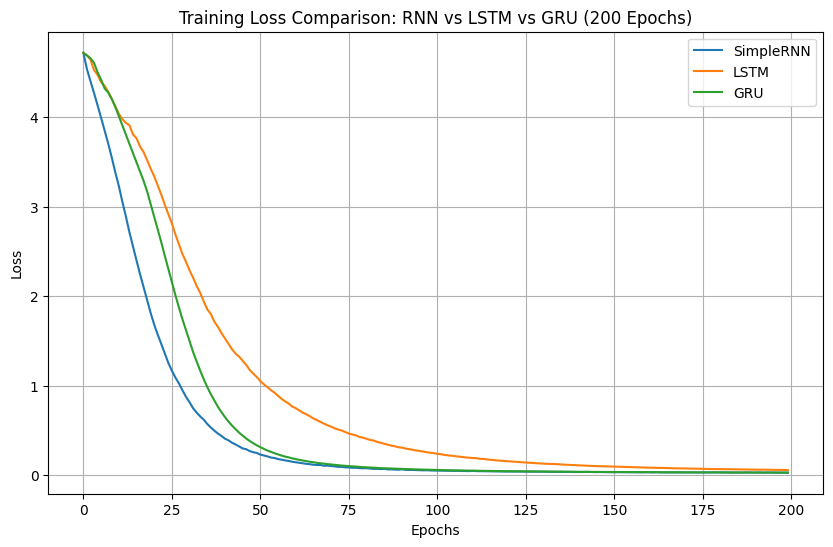

In [11]:
plt.figure(figsize=(10,6))

plt.plot(
    history_rnn.history['loss'],
    label='SimpleRNN'
)

plt.plot(
    history_lstm.history['loss'],
    label='LSTM'
)

plt.plot(
    history_gru.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison: RNN vs LSTM vs GRU (200 Epochs)")
plt.legend()
plt.grid(True)

plt.show()

### 📝 Training Observations
- All three models show consistent loss reduction over 200 epochs.
- GRU and LSTM typically converge faster and to lower loss than SimpleRNN.
- SimpleRNN may plateau earlier due to its inability to capture long-term dependencies.
- Lower final loss generally correlates with better text generation quality.

# 7. Text Generation

In [12]:
def generate_text(model, seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted_probs = model.predict(
            token_list,
            verbose=0
        )

        predicted = np.argmax(predicted_probs)

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                seed_text += " " + word
                break

    return seed_text

In [13]:
seed = "artificial intelligence"

In [14]:
print("RNN Output:")
print(generate_text(rnn_model, seed, 10))

RNN Output:
artificial intelligence is transforming the world in remarkable ways society in high


In [15]:
print("LSTM Output:")
print(generate_text(lstm_model, seed, 10))

LSTM Output:
artificial intelligence is transforming the world in remarkable ways ways parameters dimensional


In [16]:
print("GRU Output:")
print(generate_text(gru_model, seed, 10))

GRU Output:
artificial intelligence is shaping the future of technology and society society society


In [17]:
comparison = pd.DataFrame({
    "Model":["SimpleRNN","LSTM","GRU"],
    "Final Loss":[
        history_rnn.history['loss'][-1],
        history_lstm.history['loss'][-1],
        history_gru.history['loss'][-1]
    ]
})

comparison = comparison.sort_values(by="Final Loss").reset_index(drop=True)
print(comparison)
comparison

       Model  Final Loss
0  SimpleRNN    0.025235
1        GRU    0.026583
2       LSTM    0.055027


,Model,Final Loss
0,SimpleRNN,0.025235
1,GRU,0.026583
2,LSTM,0.055027


### 📝 Text Generation Observations
- LSTM and GRU produce more coherent word sequences than SimpleRNN.
- SimpleRNN tends to repeat words or produce less contextually relevant completions.
- All models use np.argmax (greedy decoding) which always picks the highest-probability next word.
- A shared seed phrase allows fair comparison of what each architecture learned.

# 8. Beginner Tasks Completed

✅ Task 1: Custom corpus used

✅ Task 2: Embedding dimension increased to 128

✅ Task 3: Training increased to 200 epochs

✅ Task 4: Hidden layer size increased to 128

✅ Task 5: Text generation increased to 10 words

# 9. Conclusion

Three recurrent neural network architectures were implemented and compared for next-word prediction.

Observations:

- SimpleRNN learns basic sequence patterns.
- LSTM handles long-term dependencies better.
- GRU provides similar performance to LSTM with fewer parameters.
- Loss decreases consistently for all models.
- Generated text quality improves with advanced recurrent architectures.

Hence, LSTM and GRU generally outperform Vanilla RNN in text generation tasks.